# 02 - Signal Generator Control and a Real RF Measurement

This notebook takes the next practical step after establishing VISA connectivity: **configure a signal generator and make a real RF measurement that matters in test engineering**.

The measurement used here is a basic but relevant one:

**verify generated CW frequency and output power with a spectrum analyzer**.

This is the foundation for many larger workflows, including gain measurements, calibration checks, compression tests, and automated RF regression testing.

## What this notebook covers

- Connecting to a signal generator and spectrum analyzer
- Setting CW frequency and power on the generator
- Enabling output safely
- Configuring the analyzer center frequency and span
- Reading marker amplitude or peak power
- Sweeping generator power and measuring reported output
- Plotting commanded vs. measured power
- Running the same workflow in mock mode when hardware is unavailable

## Why this is a real RF measurement of interest

A controlled **CW power verification** is one of the simplest measurements that is still technically useful in many other measurements.

In practice, ewe can use this test to:

- confirm that a generator is producing the intended signal,
- verify basic analyzer setup,
- check cable and attenuator losses,
- establish a baseline before testing a DUT,
- and build confidence that automation code is driving instruments correctly.

If we are interested in gain, ACPR, EVM, or compression, this type of measurement is often the first building block.

## Assumptions and notes

- SCPI syntax varies slightly by vendor.
- The commands shown here are representative and commonly close to Keysight, Rohde & Schwarz, and similar instruments.
- You should verify exact command names against your instrument programming guide.
- For safety, start with low power and ensure adequate attenuation before connecting a signal generator directly to a spectrum analyzer.

In [14]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

## Step 1: Create a VISA resource manager and inspect resources

In [15]:
rm = pyvisa.ResourceManager()
resources = rm.list_resources()
print('Discovered VISA resources:')
pprint(resources)

Discovered VISA resources:
()


## Step 2: Define helper functions

These helpers keep the notebook readable and make it easier to reuse the same logic in a future test framework.

In [16]:
def configure_common_session(inst, timeout_ms=5000):
    inst.timeout = timeout_ms
    inst.write_termination = '\n'
    inst.read_termination = '\n'
    return inst

def identify(inst):
    return inst.query('*IDN?').strip()

def safe_close(inst):
    try:
        inst.close()
    except Exception:
        pass

## Step 3: Instrument wrapper classes


In [17]:
class SignalGenerator:
    def __init__(self, inst):
        self.inst = inst

    def idn(self):
        return identify(self.inst)

    def reset(self):
        self.inst.write('*RST')

    def set_frequency_hz(self, freq_hz):
        self.inst.write(f'FREQ {freq_hz}')

    def get_frequency_hz(self):
        return float(self.inst.query('FREQ?'))

    def set_power_dbm(self, power_dbm):
        self.inst.write(f'POW {power_dbm}DBM')

    def get_power_dbm(self):
        response = self.inst.query('POW?').strip()
        return float(response)

    def output_on(self):
        self.inst.write('OUTP ON')

    def output_off(self):
        self.inst.write('OUTP OFF')


class SpectrumAnalyzer:
    def __init__(self, inst):
        self.inst = inst

    def idn(self):
        return identify(self.inst)

    def reset(self):
        self.inst.write('*RST')

    def set_center_frequency_hz(self, freq_hz):
        self.inst.write(f'FREQ:CENT {freq_hz}')

    def set_span_hz(self, span_hz):
        self.inst.write(f'FREQ:SPAN {span_hz}')

    def set_rbw_hz(self, rbw_hz):
        self.inst.write(f'BAND {rbw_hz}')

    def place_marker_at_peak(self):
        self.inst.write('CALC:MARK1:MAX')

    def marker_frequency_hz(self):
        return float(self.inst.query('CALC:MARK1:X?'))

    def marker_power_dbm(self):
        return float(self.inst.query('CALC:MARK1:Y?'))

## Step 4: Optional real-hardware connection

Update the resource strings below if you have actual instruments connected.

If you leave them as `None`, the notebook will use mock instruments later.

In [18]:
SIGGEN_RESOURCE = None
SA_RESOURCE = None

# Example values:
# SIGGEN_RESOURCE = 'TCPIP0::192.168.1.50::inst0::INSTR'
# SA_RESOURCE = 'TCPIP0::192.168.1.51::inst0::INSTR'

In [19]:
siggen = None
sa = None
real_hardware_connected = False

if SIGGEN_RESOURCE and SA_RESOURCE:
    try:
        siggen_inst = configure_common_session(rm.open_resource(SIGGEN_RESOURCE))
        sa_inst = configure_common_session(rm.open_resource(SA_RESOURCE))

        siggen = SignalGenerator(siggen_inst)
        sa = SpectrumAnalyzer(sa_inst)

        print('Signal generator:', siggen.idn())
        print('Spectrum analyzer:', sa.idn())
        real_hardware_connected = True
    except Exception as e:
        print('Real hardware connection failed:')
        print(e)

## Step 5: Mock instruments for a reproducible tutorial

These are useful for portfolio work and for writing notebook logic before entering the lab.

In [20]:
class MockSignalGeneratorInstrument:
    def __init__(self):
        self.timeout = 5000
        self.write_termination = '\n'
        self.read_termination = '\n'
        self.frequency_hz = 1e9
        self.power_dbm = -30.0
        self.output_enabled = False
        self.command_log = []

    def write(self, cmd):
        self.command_log.append(('write', cmd))
        cmd = cmd.strip().upper()
        if cmd == '*RST':
            self.frequency_hz = 1e9
            self.power_dbm = -30.0
            self.output_enabled = False
        elif cmd.startswith('FREQ '):
            self.frequency_hz = float(cmd.split()[1])
        elif cmd.startswith('POW '):
            value = cmd.split()[1].replace('DBM', '')
            self.power_dbm = float(value)
        elif cmd == 'OUTP ON':
            self.output_enabled = True
        elif cmd == 'OUTP OFF':
            self.output_enabled = False

    def query(self, cmd):
        self.command_log.append(('query', cmd))
        cmd = cmd.strip().upper()
        if cmd == '*IDN?':
            return 'MOCK,SIGGEN,1001,1.0'
        if cmd == 'FREQ?':
            return str(self.frequency_hz)
        if cmd == 'POW?':
            return str(self.power_dbm)
        return '0'

    def close(self):
        pass


class MockSpectrumAnalyzerInstrument:
    def __init__(self, siggen_source):
        self.timeout = 5000
        self.write_termination = '\n'
        self.read_termination = '\n'
        self.siggen_source = siggen_source
        self.center_hz = 1e9
        self.span_hz = 1e6
        self.rbw_hz = 1e3
        self.marker_peak_selected = False
        self.command_log = []
        self.path_loss_db = 1.2

    def write(self, cmd):
        self.command_log.append(('write', cmd))
        cmd_u = cmd.strip().upper()
        if cmd_u == '*RST':
            self.center_hz = 1e9
            self.span_hz = 1e6
            self.rbw_hz = 1e3
            self.marker_peak_selected = False
        elif cmd_u.startswith('FREQ:CENT '):
            self.center_hz = float(cmd.split()[1])
        elif cmd_u.startswith('FREQ:SPAN '):
            self.span_hz = float(cmd.split()[1])
        elif cmd_u.startswith('BAND '):
            self.rbw_hz = float(cmd.split()[1])
        elif cmd_u == 'CALC:MARK1:MAX':
            self.marker_peak_selected = True

    def query(self, cmd):
        self.command_log.append(('query', cmd))
        cmd_u = cmd.strip().upper()
        if cmd_u == '*IDN?':
            return 'MOCK,SPECTRUM-ANALYZER,2001,1.0'
        if cmd_u == 'CALC:MARK1:X?':
            return str(self.siggen_source.frequency_hz)
        if cmd_u == 'CALC:MARK1:Y?':
            if not self.siggen_source.output_enabled:
                return '-120.0'
            measured = self.siggen_source.power_dbm - self.path_loss_db
            return str(measured)
        return '0'

    def close(self):
        pass

In [21]:
if not real_hardware_connected:
    mock_siggen_inst = MockSignalGeneratorInstrument()
    mock_sa_inst = MockSpectrumAnalyzerInstrument(mock_siggen_inst)
    siggen = SignalGenerator(mock_siggen_inst)
    sa = SpectrumAnalyzer(mock_sa_inst)
    print('Using mock instruments for tutorial execution.')
    print('Signal generator:', siggen.idn())
    print('Spectrum analyzer:', sa.idn())

Using mock instruments for tutorial execution.
Signal generator: MOCK,SIGGEN,1001,1.0
Spectrum analyzer: MOCK,SPECTRUM-ANALYZER,2001,1.0


## Step 6: Configure a CW output and verify it on the analyzer

In [22]:
test_frequency_hz = 1.0e9
test_power_dbm = -20.0
test_span_hz = 2.0e6
test_rbw_hz = 1.0e3

siggen.reset()
sa.reset()

siggen.set_frequency_hz(test_frequency_hz)
siggen.set_power_dbm(test_power_dbm)
siggen.output_on()

sa.set_center_frequency_hz(test_frequency_hz)
sa.set_span_hz(test_span_hz)
sa.set_rbw_hz(test_rbw_hz)
sa.place_marker_at_peak()

commanded_freq = siggen.get_frequency_hz()
commanded_power = siggen.get_power_dbm()
measured_freq = sa.marker_frequency_hz()
measured_power = sa.marker_power_dbm()

print(f'Commanded frequency: {commanded_freq/1e6:.3f} MHz')
print(f'Commanded power:     {commanded_power:.2f} dBm')
print(f'Measured frequency:  {measured_freq/1e6:.3f} MHz')
print(f'Measured power:      {measured_power:.2f} dBm')

Commanded frequency: 1000.000 MHz
Commanded power:     -20.00 dBm
Measured frequency:  1000.000 MHz
Measured power:      -21.20 dBm


## Interpreting the result

If the measured power is lower than the commanded generator power, that is usually expected.

Possible reasons include:

- cable loss,
- external attenuators,
- connector mismatch,
- analyzer amplitude accuracy,
- or reference level / setup issues.

In the mock example, a fixed path loss is intentionally modeled so the analyzer reading is lower than the commanded power.

## Step 7: Sweep generator power and record analyzer measurements

This is the most important part of the notebook. A power sweep is a simple, real measurement pattern used constantly in RF labs.

In [23]:
power_sweep_dbm = np.arange(-30, 1, 5)
measured_powers_dbm = []
frequency_used_hz = 1.0e9

siggen.set_frequency_hz(frequency_used_hz)
sa.set_center_frequency_hz(frequency_used_hz)
sa.set_span_hz(2.0e6)
sa.set_rbw_hz(1.0e3)
siggen.output_on()

for p_dbm in power_sweep_dbm:
    siggen.set_power_dbm(float(p_dbm))
    sa.place_marker_at_peak()
    measured = sa.marker_power_dbm()
    measured_powers_dbm.append(measured)

power_sweep_dbm = np.array(power_sweep_dbm, dtype=float)
measured_powers_dbm = np.array(measured_powers_dbm, dtype=float)

for commanded, measured in zip(power_sweep_dbm, measured_powers_dbm):
    print(f'Commanded: {commanded:6.1f} dBm   Measured: {measured:6.2f} dBm')

Commanded:  -30.0 dBm   Measured: -31.20 dBm
Commanded:  -25.0 dBm   Measured: -26.20 dBm
Commanded:  -20.0 dBm   Measured: -21.20 dBm
Commanded:  -15.0 dBm   Measured: -16.20 dBm
Commanded:  -10.0 dBm   Measured: -11.20 dBm
Commanded:   -5.0 dBm   Measured:  -6.20 dBm
Commanded:    0.0 dBm   Measured:  -1.20 dBm


## Step 8: Plot commanded vs. measured power

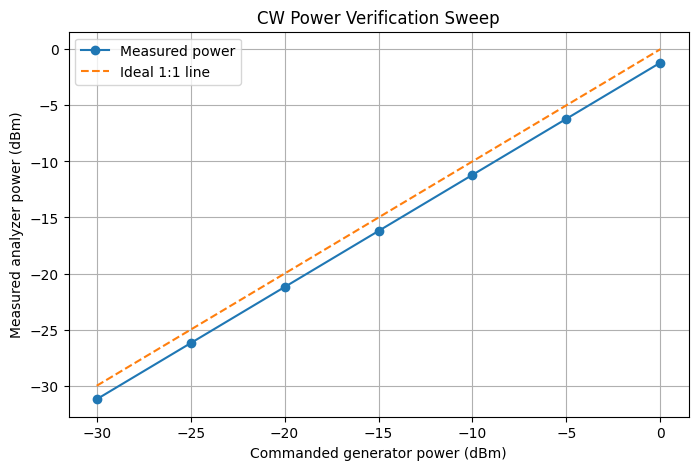

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(power_sweep_dbm, measured_powers_dbm, marker='o', label='Measured power')
plt.plot(power_sweep_dbm, power_sweep_dbm, linestyle='--', label='Ideal 1:1 line')
plt.xlabel('Commanded generator power (dBm)')
plt.ylabel('Measured analyzer power (dBm)')
plt.title('CW Power Verification Sweep')
plt.grid(True)
plt.legend()
plt.show()

## Step 9: Estimate path loss or amplitude offset

For a simple direct connection, the difference between commanded and measured power provides a first-order estimate of the total path loss or measurement offset.

In [25]:
delta_db = measured_powers_dbm - power_sweep_dbm
mean_offset_db = np.mean(delta_db)
std_offset_db = np.std(delta_db)

print(f'Average measured - commanded offset: {mean_offset_db:.2f} dB')
print(f'Offset standard deviation:            {std_offset_db:.2f} dB')

Average measured - commanded offset: -1.20 dB
Offset standard deviation:            0.00 dB


## Summary
This notebook provides sample code for simulating and testing several topics in RF measurement: 

- How to structure instrument drivers in Python
- Why `*IDN?` is only the first step and not a full connectivity check
- Why analyzer settings like center frequency, span, and RBW matter
- Why measured power can differ from commanded power
- How to turn a manual bench check into an automated regression test

## Extensions you can build next

Natural follow-ons from this notebook are:

- frequency sweep at constant power,
- cable loss characterization vs. frequency,
- DUT insertion gain or loss measurement,
- compression test by looking for deviation from linear response,
- or capturing full trace data instead of only marker results.

In [27]:
# Safe cleanup
try:
    siggen.output_off()
except Exception:
    pass

print('RF output disabled at end of notebook.')

RF output disabled at end of notebook.
